In [1]:
!pip install -U gdown

In [2]:
import gdown

# Remplace the ID by yours (everything from /d to /view)
file_id = '1qKLrT6b94vRv3Yug8Fdol1aWYRfok3US'
url = f'https://drive.google.com/uc?id={file_id}'

# Downloading
gdown.download(url, 'fb.csv', quiet=False)

# Read the CSV file
import pandas as pd
df = pd.read_csv('fb.csv')
df.head()

Downloading...
From: https://drive.google.com/uc?id=1qKLrT6b94vRv3Yug8Fdol1aWYRfok3US
To: /content/fb.csv
100%|██████████| 21.7k/21.7k [00:00<00:00, 27.9MB/s]


,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798


In [3]:
# Inspection of missing values in the dataset
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

Country name                                  0.0
Regional indicator                            0.0
Ladder score                                  0.0
Standard error of ladder score                0.0
upperwhisker                                  0.0
lowerwhisker                                  0.0
Logged GDP per capita                         0.0
Social support                                0.0
Healthy life expectancy                       0.0
Freedom to make life choices                  0.0
Generosity                                    0.0
Perceptions of corruption                     0.0
Ladder score in Dystopia                      0.0
Explained by: Log GDP per capita              0.0
Explained by: Social support                  0.0
Explained by: Healthy life expectancy         0.0
Explained by: Freedom to make life choices    0.0
Explained by: Generosity                      0.0
Explained by: Perceptions of corruption       0.0
Dystopia + residual                           0.0


0


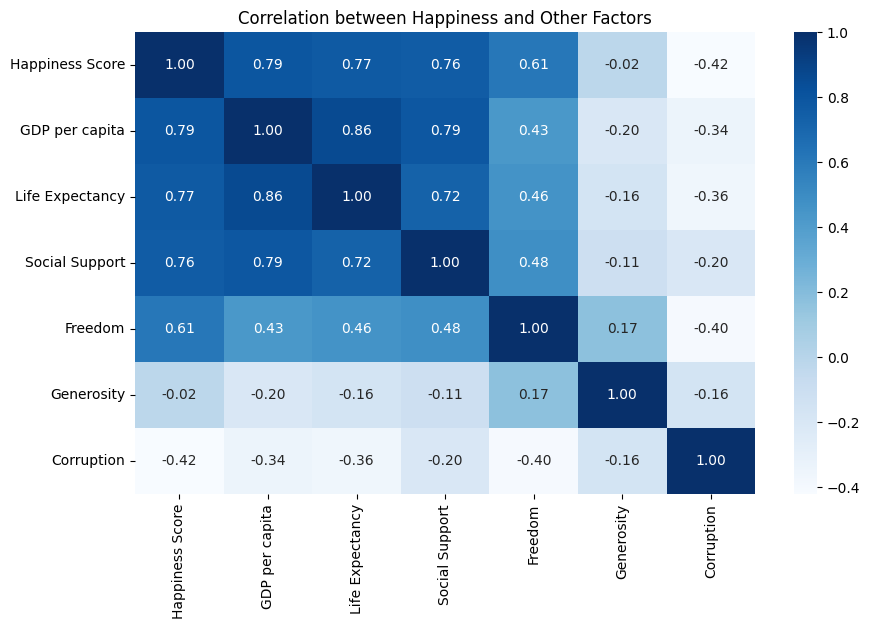

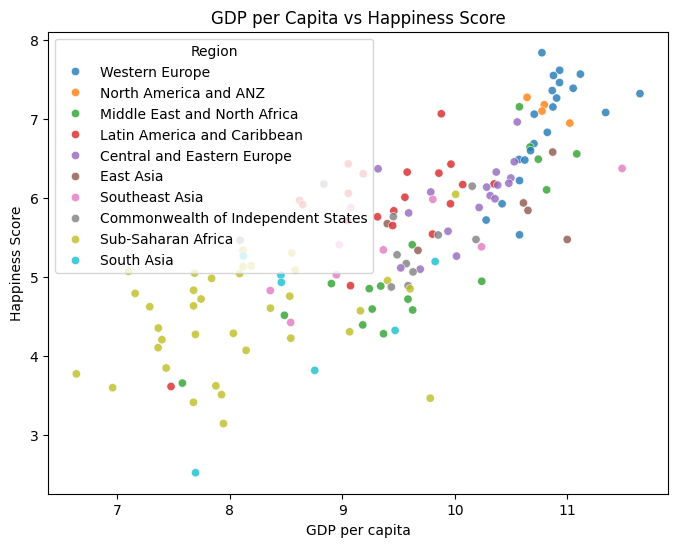

/tmp/ipykernel_14086/2931917932.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Happiness Score", y="Country", data=top10, palette="viridis")


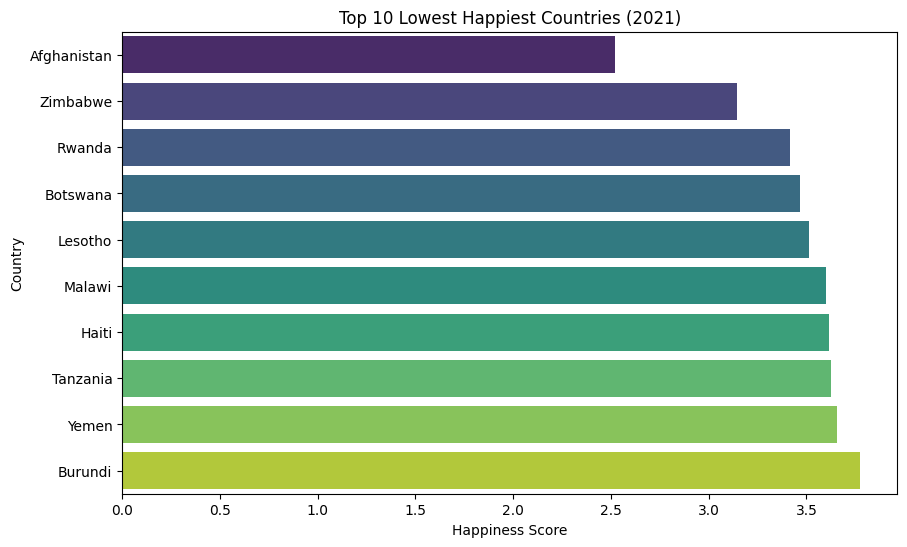

/tmp/ipykernel_14086/2931917932.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Happiness Score", y="Country", data=top10, palette="viridis")


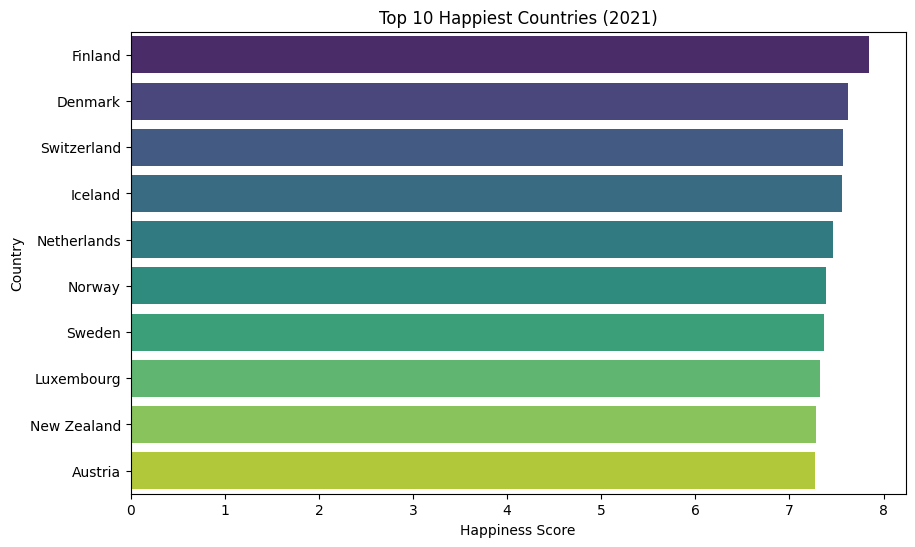

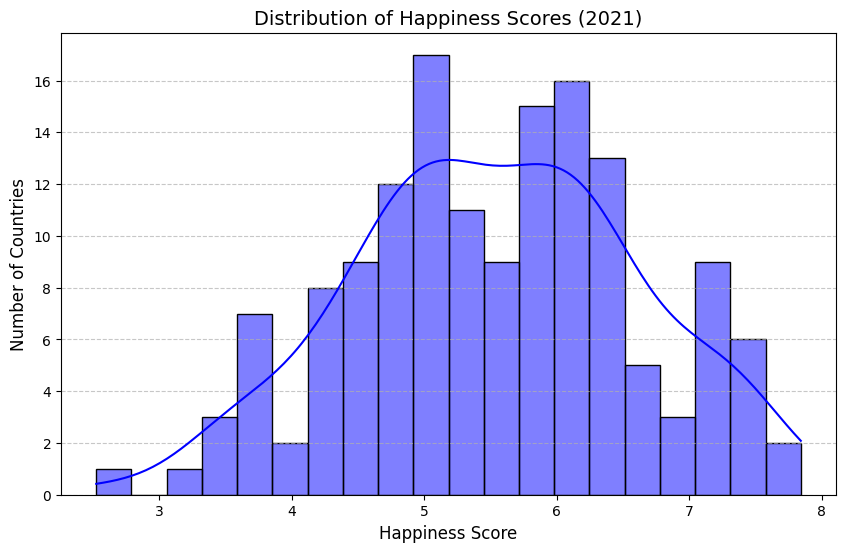

In [12]:
# Check for duplicate rows
print(df.duplicated().sum())

### 📊 II. Data Visualization

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# Rename columns for easier access
df = df.rename(columns={
    "Country name": "Country",
    "Regional indicator": "Region",
    "Ladder score": "Happiness Score",
    "Logged GDP per capita": "GDP per capita",
    "Healthy life expectancy": "Life Expectancy",
    "Social support": "Social Support",
    "Freedom to make life choices": "Freedom",
    "Generosity": "Generosity",
    "Perceptions of corruption": "Corruption"
})

# Drop missing rows
df = df.dropna()


#### 🔸 Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df[["Happiness Score","GDP per capita","Life Expectancy",
                "Social Support","Freedom","Generosity","Corruption"]].corr(),
            annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation between Happiness and Other Factors")
plt.show()

#### 🔸 GDP vs Happiness

plt.figure(figsize=(8,6))
sns.scatterplot(x="GDP per capita", y="Happiness Score", hue="Region", data=df, alpha=0.8)
plt.title("GDP per Capita vs Happiness Score")
plt.show()

#### 🔸 Top 10 Lowest Happiest Countries (2021)

top10 = df.nsmallest(10, "Happiness Score")
plt.figure(figsize=(10,6))
sns.barplot(x="Happiness Score", y="Country", data=top10, palette="viridis")
plt.title("Top 10 Lowest Happiest Countries (2021)")
plt.xlabel("Happiness Score")
plt.ylabel("Country")
plt.show()


#### 🔸 Top 10 Happiest Countries (2021)

top10 = df.nlargest(10, "Happiness Score")
plt.figure(figsize=(10,6))
sns.barplot(x="Happiness Score", y="Country", data=top10, palette="viridis")
plt.title("Top 10 Happiest Countries (2021)")
plt.xlabel("Happiness Score")
plt.ylabel("Country")
plt.show()

#### 🔸 Distribution of Happiness Scores (2021)

plt.figure(figsize=(10, 6))
sns.histplot(df["Happiness Score"], bins=20, kde=True, color="blue")
plt.title("Distribution of Happiness Scores (2021)", fontsize=14)
plt.xlabel("Happiness Score", fontsize=12)
plt.ylabel("Number of Countries", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 📊 Results Summary

 ## Strong positive correlation between **GDP per capita** and **Happiness Score**.
 ## Social Support** and **Freedom** also show positive relationships with happiness.
 ## Higher perceived **corruption** tends to reduce happiness levels.
 ## Most countries’ happiness scores are between 5 and 6.


## 🙌 Acknowledgements

## Dataset:** [World Happiness Report 2021](https://worldhappiness.report/)
## Libraries:** pandas, seaborn, matplotlib, numpy, gdown

## 👤 Authors

## Lais, Aga, Bahador
